In [1]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [2]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

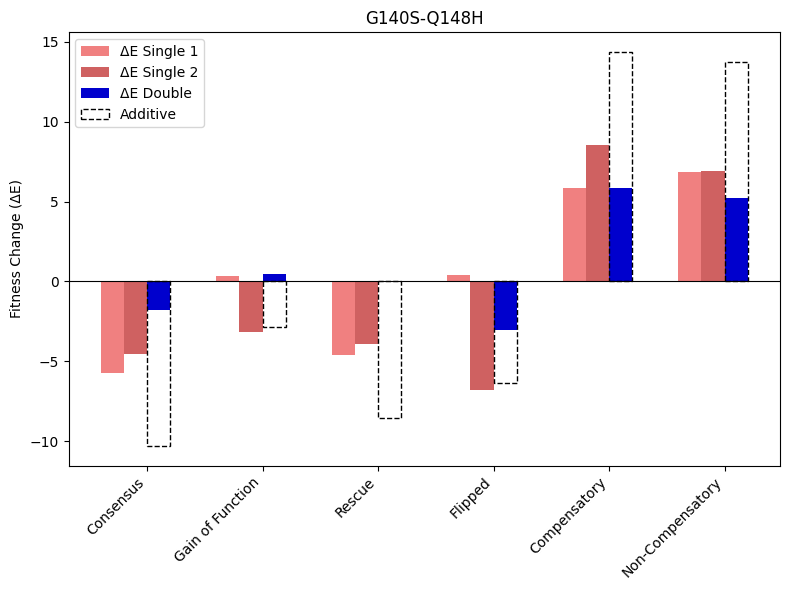

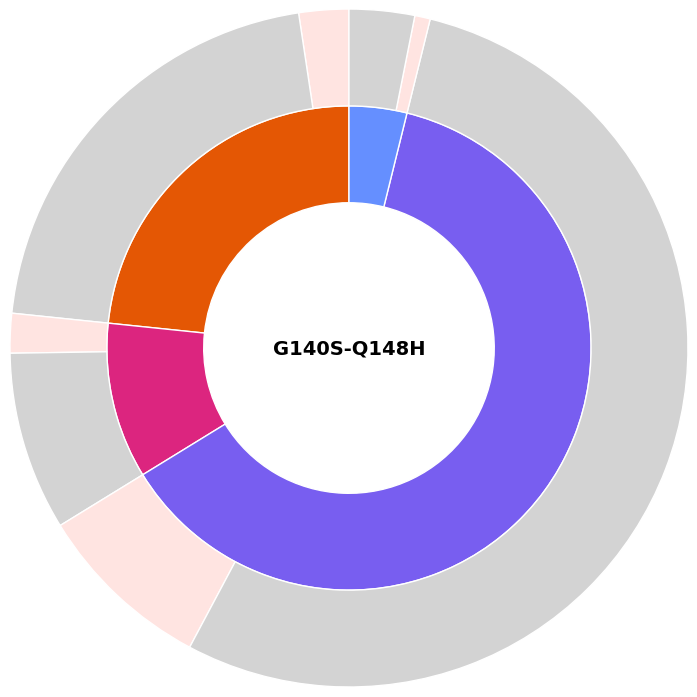

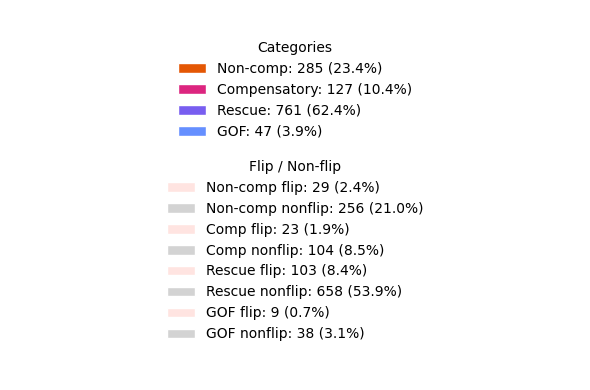

In [3]:
IN_pair = 'G140S-Q148H'
# IN_pair = 'Y143C-S230R'
# IN_pair = 'G140A-Q148K'
# IN_pair = 'G140S-Q148R'
# IN_pair = 'G140S-Q148K'

# IN_pair = 'Y143R-N155H'
pair1, pair2 = functions.split_pairs(IN_pair)
p1_reduced = functions.unreduced_to_reduced(IN_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(IN_redux, pair2)

IN_bars = []
IN_gof_bars = []
IN_rescue_bars = []
IN_flipped_bars = []
IN_compensatory_bars = []
IN_other_bars = []

gof_counts = 0
gof_flip = 0
gof_nonflip = 0

rescue_count = 0
rescue_flip = 0
rescue_nonflip = 0

compensatory_counts = 0
compensatory_flip = 0
compensatory_nonflip = 0


noncompensatory_counts = 0
noncompensatory_flip = 0
noncompensatory_nonflip = 0



consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, IN_consensus_seq, IN_J, 1, 263)
consensus_flip_relation = consensus_result[0] - consensus_result[1]

for IN_seq in IN_all_seq:
    # Debugging: Print inputs to the function

    result_wom = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, IN_seq, IN_J, 1, 263)
    result_wm = functions.calculate_with_double_mutation_dde(p1_reduced, p2_reduced, IN_seq, IN_J, 1, 263)
    # Check if the result is None

    if result_wom is None:
        continue 
    pair1_de, pair2_de, pair12_de, pair12_dde = result_wom

    # if result_wm is None:
    #     continue 
    # pair1_de, pair2_de, pair12_de, pair12_dde = result_wm

    if pair1_de < pair12_de and pair2_de < pair12_de and pair12_de >0:
        IN_gof_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
        gof_counts += 1

        if (pair1_de - pair2_de)*consensus_flip_relation < 0:
            IN_flipped_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
            gof_flip += 1
        else: 
            gof_nonflip += 1

    elif pair1_de < pair12_de and pair2_de < pair12_de:
        IN_rescue_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
        rescue_count += 1
        if (pair1_de - pair2_de)*consensus_flip_relation < 0:
            IN_flipped_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
            rescue_flip += 1
        else: 
            rescue_nonflip += 1

    elif pair1_de < pair12_de or pair2_de < pair12_de:
        IN_compensatory_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
        compensatory_counts += 1
        if (pair1_de - pair2_de)*consensus_flip_relation < 0:
            IN_flipped_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
            compensatory_flip += 1
        else: 
            compensatory_nonflip += 1
    else:
        IN_other_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
        noncompensatory_counts += 1
        if (pair1_de - pair2_de)*consensus_flip_relation < 0:
            IN_flipped_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
            noncompensatory_flip += 1
        else: 
            noncompensatory_nonflip += 1

IN_rescue_bars.sort(key=lambda x: x[3], reverse=True)
IN_flipped_bars.sort(key=lambda x: abs(x[1]-x[2]), reverse=True)
IN_compensatory_bars.sort(key=lambda x: x[3], reverse=True)
IN_other_bars.sort(key=lambda x: x[3], reverse=True)

IN_bars.insert(0, ('Consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
# print("IN_bars:", IN_bars)
if IN_gof_bars:
    IN_bars.insert(1, ('Gain of Function', IN_gof_bars[0][1], IN_gof_bars[0][2], IN_gof_bars[0][3]))
if IN_rescue_bars:
    IN_bars.insert(2, ('Rescue', IN_rescue_bars[0][1], IN_rescue_bars[0][2], IN_rescue_bars[0][3]))
if IN_flipped_bars:
    IN_bars.insert(3, ('Flipped', IN_flipped_bars[0][1], IN_flipped_bars[0][2], IN_flipped_bars[0][3]))
if IN_compensatory_bars:
    IN_bars.insert(4, ('Compensatory', IN_compensatory_bars[0][1], IN_compensatory_bars[0][2], IN_compensatory_bars[0][3]))
if IN_other_bars:
    IN_bars.insert(5, ('Non-Compensatory', IN_other_bars[0][1], IN_other_bars[0][2], IN_other_bars[0][3]))
plot.plot_epistatic_bar(IN_pair,IN_bars[:6])

plot.epistatic_pie2(IN_pair, compensatory_flip, compensatory_nonflip, noncompensatory_flip, noncompensatory_nonflip, rescue_flip, rescue_nonflip, gof_flip, gof_nonflip)

In [4]:
# import matplotlib.pyplot as plt
# # Set x-axis limits for all plots
# bin_num = 50
# # Extract values for gof and rescue
# gof_de12 = [x[3] for x in IN_gof_bars]
# gof_de1 = [x[1] for x in IN_gof_bars]
# gof_de2 = [x[2] for x in IN_gof_bars]

# rescue_de12 = [x[3] for x in IN_rescue_bars]
# rescue_de1 = [x[1] for x in IN_rescue_bars]
# rescue_de2 = [x[2] for x in IN_rescue_bars]

# # Create subplots for histograms
# fig, axes = plt.subplots(4, 3, figsize=(15, 20))

# # Plot histograms for gof
# axes[0, 0].hist(gof_de12, bins=bin_num, color='blue', alpha=0.7)
# axes[0, 0].set_title('GOF de12 Distribution')
# axes[0, 0].set_xlabel('de12')
# axes[0, 0].set_ylabel('Frequency')

# axes[0, 1].hist(gof_de1, bins=bin_num, color='green', alpha=0.7)
# axes[0, 1].set_title('GOF de1 Distribution')
# axes[0, 1].set_xlabel('de1')
# axes[0, 1].set_ylabel('Frequency')

# axes[0, 2].hist(gof_de2, bins=bin_num, color='red', alpha=0.7)
# axes[0, 2].set_title('GOF de2 Distribution')
# axes[0, 2].set_xlabel('de2')
# axes[0, 2].set_ylabel('Frequency')

# # Plot histograms for rescue
# axes[1, 0].hist(rescue_de12, bins=bin_num, color='blue', alpha=0.7)
# axes[1, 0].set_title('Rescue de12 Distribution')
# axes[1, 0].set_xlabel('de12')
# axes[1, 0].set_ylabel('Frequency')

# axes[1, 1].hist(rescue_de1, bins=bin_num, color='green', alpha=0.7)
# axes[1, 1].set_title('Rescue de1 Distribution')
# axes[1, 1].set_xlabel('de1')
# axes[1, 1].set_ylabel('Frequency')

# axes[1, 2].hist(rescue_de2, bins=bin_num, color='red', alpha=0.7)
# axes[1, 2].set_title('Rescue de2 Distribution')
# axes[1, 2].set_xlabel('de2')
# axes[1, 2].set_ylabel('Frequency')

# # Extract values for complementary and non-complementary
# comp_de12 = [x[3] for x in IN_compensatory_bars]
# comp_de1 = [x[1] for x in IN_compensatory_bars]
# comp_de2 = [x[2] for x in IN_compensatory_bars]

# noncomp_de12 = [x[3] for x in IN_other_bars]
# noncomp_de1 = [x[1] for x in IN_other_bars]
# noncomp_de2 = [x[2] for x in IN_other_bars]

# # Create subplots for complementary and non-complementary histograms
# # fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# # Plot histograms for complementary
# axes[2, 0].hist(comp_de12, bins=bin_num, color='blue', alpha=0.7)
# axes[2, 0].set_title('Complementary de12 Distribution')
# axes[2, 0].set_xlabel('de12')
# axes[2, 0].set_ylabel('Frequency')

# axes[2, 1].hist(comp_de1, bins=bin_num, color='green', alpha=0.7)
# axes[2, 1].set_title('Complementary de1 Distribution')
# axes[2, 1].set_xlabel('de1')
# axes[2, 1].set_ylabel('Frequency')

# axes[2, 2].hist(comp_de2, bins=bin_num, color='red', alpha=0.7)
# axes[2, 2].set_title('Complementary de2 Distribution')
# axes[2, 2].set_xlabel('de2')
# axes[2, 2].set_ylabel('Frequency')

# # Plot histograms for non-complementary
# axes[3, 0].hist(noncomp_de12, bins=bin_num, color='blue', alpha=0.7)
# axes[3, 0].set_title('Non-Complementary de12 Distribution')
# axes[3, 0].set_xlabel('de12')
# axes[3, 0].set_ylabel('Frequency')

# axes[3, 1].hist(noncomp_de1, bins=bin_num, color='green', alpha=0.7)
# axes[3, 1].set_title('Non-Complementary de1 Distribution')
# axes[3, 1].set_xlabel('de1')
# axes[3, 1].set_ylabel('Frequency')

# axes[3, 2].hist(noncomp_de2, bins=bin_num, color='red', alpha=0.7)
# axes[3, 2].set_title('Non-Complementary de2 Distribution')
# axes[3, 2].set_xlabel('de2')
# axes[3, 2].set_ylabel('Frequency')

# # Adjust layout and show the plot
# for ax in axes.flatten():
#     ax.set_ylim(0, 50)
#     ax.set_xlim(-12, 3)
# plt.tight_layout()
# plt.show()

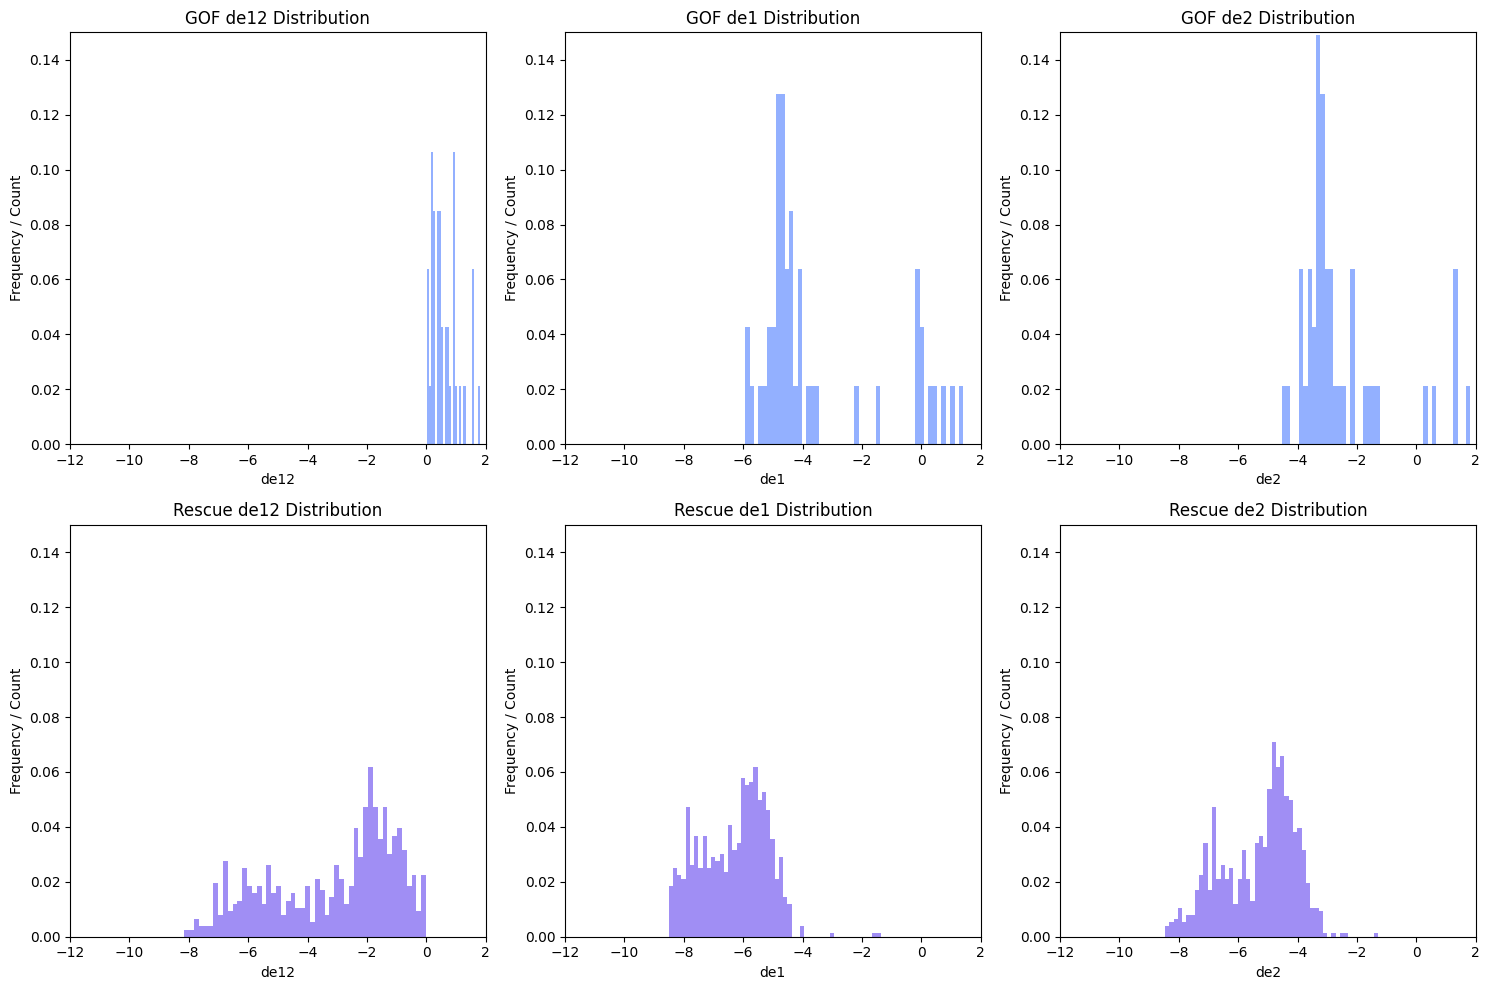

In [5]:
import matplotlib.pyplot as plt
# Set x-axis limits for all plots
bin_num = 50
# Extract values for gof and rescue
gof_de12 = [x[3] for x in IN_gof_bars]
gof_de1 = [x[1] for x in IN_gof_bars]
gof_de2 = [x[2] for x in IN_gof_bars]

rescue_de12 = [x[3] for x in IN_rescue_bars]
rescue_de1 = [x[1] for x in IN_rescue_bars]
rescue_de2 = [x[2] for x in IN_rescue_bars]

# Create subplots for histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot histograms for gof
axes[0, 0].hist(gof_de12, bins=bin_num, color='blue', alpha=0.7, weights=[1/gof_counts]*len(gof_de12))
axes[0, 0].set_title('GOF de12 Distribution')
axes[0, 0].set_xlabel('de12')
axes[0, 0].set_ylabel('Frequency / Count')

axes[0, 1].hist(gof_de1, bins=bin_num, color='green', alpha=0.7, weights=[1/gof_counts]*len(gof_de1))
axes[0, 1].set_title('GOF de1 Distribution')
axes[0, 1].set_xlabel('de1')
axes[0, 1].set_ylabel('Frequency / Count')

axes[0, 2].hist(gof_de2, bins=bin_num, color='red', alpha=0.7, weights=[1/gof_counts]*len(gof_de2))
axes[0, 2].set_title('GOF de2 Distribution')
axes[0, 2].set_xlabel('de2')
axes[0, 2].set_ylabel('Frequency / Count')

# Plot histograms for rescue
axes[1, 0].hist(rescue_de12, bins=bin_num, color='blue', alpha=0.7, weights=[1/rescue_count]*len(rescue_de12))
axes[1, 0].set_title('Rescue de12 Distribution')
axes[1, 0].set_xlabel('de12')
axes[1, 0].set_ylabel('Frequency / Count')

axes[1, 1].hist(rescue_de1, bins=bin_num, color='green', alpha=0.7, weights=[1/rescue_count]*len(rescue_de1))
axes[1, 1].set_title('Rescue de1 Distribution')
axes[1, 1].set_xlabel('de1')
axes[1, 1].set_ylabel('Frequency / Count')

axes[1, 2].hist(rescue_de2, bins=bin_num, color='red', alpha=0.7, weights=[1/rescue_count]*len(rescue_de2))
axes[1, 2].set_title('Rescue de2 Distribution')
axes[1, 2].set_xlabel('de2')
axes[1, 2].set_ylabel('Frequency / Count')

# Adjust layout and show the plot
colors = ['#658fff', '#785ef0']  # Blue for GOF, Orange for Rescue histograms

# Set colors for each histogram
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        for patch in ax.patches:
            patch.set_facecolor(colors[i])

for ax in axes.flatten():
    ax.set_ylim(0, 0.15)  # Adjusted for frequency
    ax.set_xlim(-12, 2)

plt.tight_layout()
plt.show()


In [6]:
# import matplotlib.pyplot as plt

# # Data for box plots
# data_de12 = [gof_de12, rescue_de12, comp_de12, noncomp_de12]
# data_de1 = [gof_de1, rescue_de1, comp_de1, noncomp_de1]
# data_de2 = [gof_de2, rescue_de2, comp_de2, noncomp_de2]

# # Labels for the categories
# labels = ['GOF', 'Rescue', 'Complementary', 'Non-Complementary']

# # Colors for the boxes
# # colors = ['#6a1a9b', '#ffb300', '#2b752f', '#c62828']

# colors = ['#658fff','#785ef0','#dc257f','#e45704']

# # Create subplots for the box plots
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# # Box plot for de12
# bplot1 = axes[0].boxplot(data_de12, patch_artist=True, labels=labels)
# for patch, color in zip(bplot1['boxes'], colors):
#     patch.set_facecolor(color)
# axes[0].set_title('de12 Distribution')
# axes[0].set_ylabel('de12')

# # Box plot for de1
# bplot2 = axes[1].boxplot(data_de1, patch_artist=True, labels=labels)
# for patch, color in zip(bplot2['boxes'], colors):
#     patch.set_facecolor(color)
# axes[1].set_title('de1 Distribution')
# axes[1].set_ylabel('de1')

# # Box plot for de2
# bplot3 = axes[2].boxplot(data_de2, patch_artist=True, labels=labels)
# for patch, color in zip(bplot3['boxes'], colors):
#     patch.set_facecolor(color)
# axes[2].set_title('de2 Distribution')
# axes[2].set_ylabel('de2')

# # Adjust layout and show the plot
# plt.tight_layout()
# plt.show()

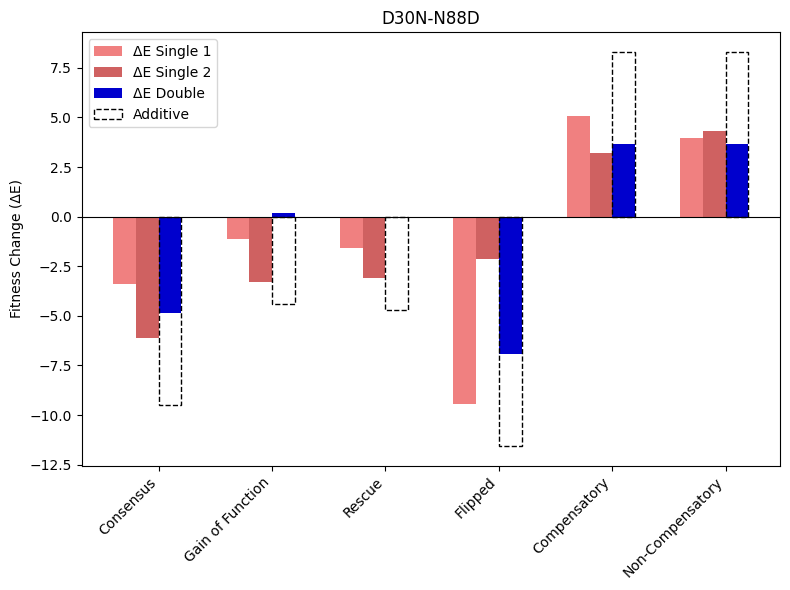

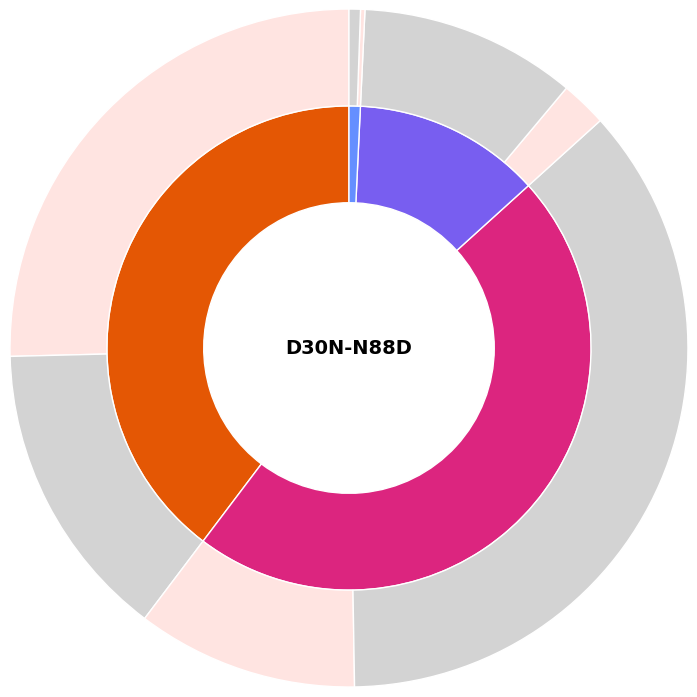

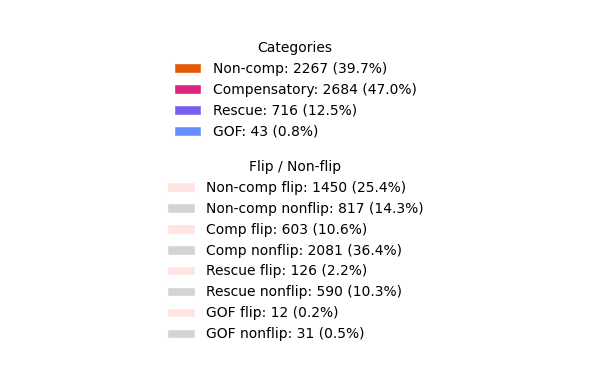

In [7]:
PR_pair = 'D30N-N88D'
# PR_pair = 'V32I-I47V'
# PR_pair = 'G48V-I54A'
# PR_pair = 'D30N-K45Q'
# PR_pair = 'I54A-V82A'

pair1, pair2 = functions.split_pairs(PR_pair)
p1_reduced = functions.unreduced_to_reduced(PR_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(PR_redux, pair2)

PR_bars = []
PR_gof_bars = []
PR_rescue_bars = []
PR_flipped_bars = []
PR_compensatory_bars = []
PR_other_bars = []

gof_counts = 0
gof_flip = 0
gof_nonflip = 0

rescue_count = 0
rescue_flip = 0
rescue_nonflip = 0

compensatory_counts = 0
compensatory_flip = 0
compensatory_nonflip = 0

noncompensatory_counts = 0
noncompensatory_flip = 0
noncompensatory_nonflip = 0

consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, PR_consensus_seq, PR_J, 1, 99)
consensus_flip_relation = consensus_result[0] - consensus_result[1]

for PR_seq in PR_all_seq:
    result_wom = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, PR_seq, PR_J, 1, 99)
    result_wm = functions.calculate_with_double_mutation_dde(p1_reduced, p2_reduced, PR_seq, PR_J, 1, 99)

    if result_wom is None:
        continue
    pair1_de, pair2_de, pair12_de, pair12_dde = result_wom

    # if result_wm is None:
    #     continue 
    # pair1_de, pair2_de, pair12_de, pair12_dde = result_wm

    if pair1_de < pair12_de and pair2_de < pair12_de and pair12_de > 0:
        PR_gof_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
        gof_counts += 1

        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            PR_flipped_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
            gof_flip += 1
        else:
            gof_nonflip += 1

    elif pair1_de < pair12_de and pair2_de < pair12_de:
        PR_rescue_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
        rescue_count += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            PR_flipped_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
            rescue_flip += 1
        else:
            rescue_nonflip += 1

    elif pair1_de < pair12_de or pair2_de < pair12_de:
        PR_compensatory_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
        compensatory_counts += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            PR_flipped_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
            compensatory_flip += 1
        else:
            compensatory_nonflip += 1
    else:
        PR_other_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
        noncompensatory_counts += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            PR_flipped_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
            noncompensatory_flip += 1
        else:
            noncompensatory_nonflip += 1

PR_rescue_bars.sort(key=lambda x: x[3], reverse=True)
PR_flipped_bars.sort(key=lambda x: abs(x[1] - x[2]), reverse=True)
PR_compensatory_bars.sort(key=lambda x: x[3], reverse=True)
PR_other_bars.sort(key=lambda x: x[3], reverse=True)

PR_bars.insert(0, ('Consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
if PR_gof_bars:
    PR_bars.insert(1, ('Gain of Function', PR_gof_bars[0][1], PR_gof_bars[0][2], PR_gof_bars[0][3]))
if PR_rescue_bars:
    PR_bars.insert(2, ('Rescue', PR_rescue_bars[0][1], PR_rescue_bars[0][2], PR_rescue_bars[0][3]))
if PR_flipped_bars:
    PR_bars.insert(3, ('Flipped', PR_flipped_bars[0][1], PR_flipped_bars[0][2], PR_flipped_bars[0][3]))
if PR_compensatory_bars:
    PR_bars.insert(4, ('Compensatory', PR_compensatory_bars[0][1], PR_compensatory_bars[0][2], PR_compensatory_bars[0][3]))
if PR_other_bars:
    PR_bars.insert(5, ('Non-Compensatory', PR_other_bars[0][1], PR_other_bars[0][2], PR_other_bars[0][3]))

plot.plot_epistatic_bar(PR_pair, PR_bars[:6])

plot.epistatic_pie2(PR_pair, compensatory_flip, compensatory_nonflip, noncompensatory_flip, noncompensatory_nonflip, rescue_flip, rescue_nonflip, gof_flip, gof_nonflip)

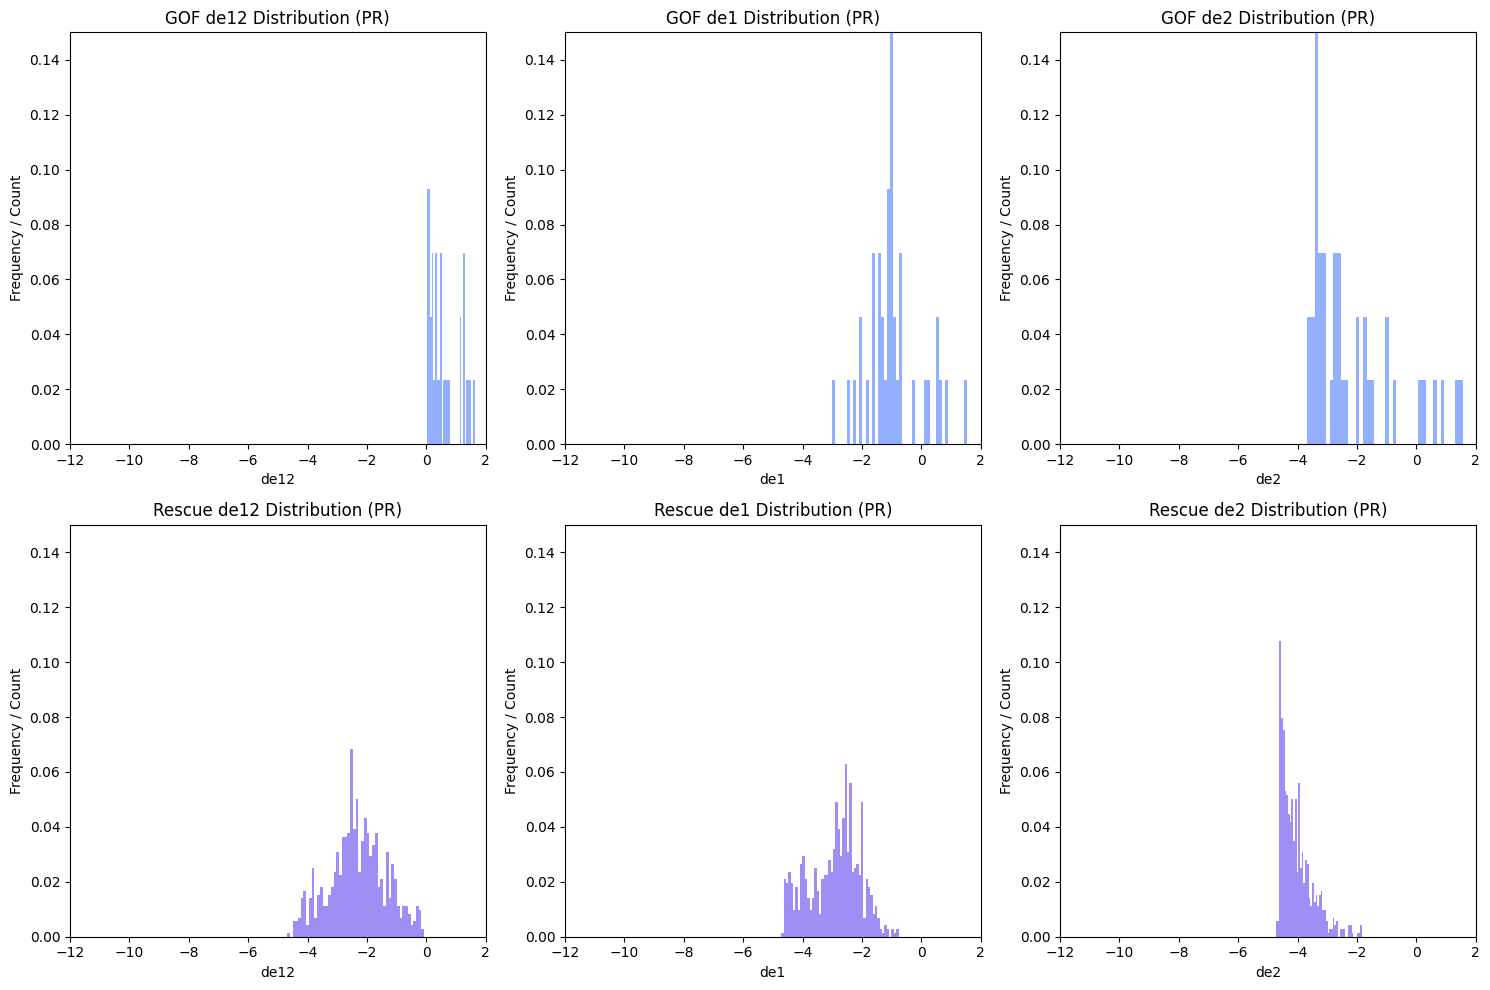

In [8]:
# Extract values for gof and rescue for PR
gof_de12 = [x[3] for x in PR_gof_bars]
gof_de1 = [x[1] for x in PR_gof_bars]
gof_de2 = [x[2] for x in PR_gof_bars]

rescue_de12 = [x[3] for x in PR_rescue_bars]
rescue_de1 = [x[1] for x in PR_rescue_bars]
rescue_de2 = [x[2] for x in PR_rescue_bars]

# Create subplots for histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot histograms for gof
axes[0, 0].hist(gof_de12, bins=bin_num, color='blue', alpha=0.7, weights=[1/gof_counts]*len(gof_de12))
axes[0, 0].set_title('GOF de12 Distribution (PR)')
axes[0, 0].set_xlabel('de12')
axes[0, 0].set_ylabel('Frequency / Count')

axes[0, 1].hist(gof_de1, bins=bin_num, color='green', alpha=0.7, weights=[1/gof_counts]*len(gof_de1))
axes[0, 1].set_title('GOF de1 Distribution (PR)')
axes[0, 1].set_xlabel('de1')
axes[0, 1].set_ylabel('Frequency / Count')

axes[0, 2].hist(gof_de2, bins=bin_num, color='red', alpha=0.7, weights=[1/gof_counts]*len(gof_de2))
axes[0, 2].set_title('GOF de2 Distribution (PR)')
axes[0, 2].set_xlabel('de2')
axes[0, 2].set_ylabel('Frequency / Count')

# Plot histograms for rescue
axes[1, 0].hist(rescue_de12, bins=bin_num, color='blue', alpha=0.7, weights=[1/rescue_count]*len(rescue_de12))
axes[1, 0].set_title('Rescue de12 Distribution (PR)')
axes[1, 0].set_xlabel('de12')
axes[1, 0].set_ylabel('Frequency / Count')

axes[1, 1].hist(rescue_de1, bins=bin_num, color='green', alpha=0.7, weights=[1/rescue_count]*len(rescue_de1))
axes[1, 1].set_title('Rescue de1 Distribution (PR)')
axes[1, 1].set_xlabel('de1')
axes[1, 1].set_ylabel('Frequency / Count')

axes[1, 2].hist(rescue_de2, bins=bin_num, color='red', alpha=0.7, weights=[1/rescue_count]*len(rescue_de2))
axes[1, 2].set_title('Rescue de2 Distribution (PR)')
axes[1, 2].set_xlabel('de2')
axes[1, 2].set_ylabel('Frequency / Count')

# Adjust layout and show the plot
colors = ['#658fff', '#785ef0']  # Blue for GOF, Orange for Rescue histograms

# Set colors for each histogram
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        for patch in ax.patches:
            patch.set_facecolor(colors[i])

for ax in axes.flatten():
    ax.set_ylim(0, 0.15)  # Adjusted for frequency
    ax.set_xlim(-12, 2)

plt.tight_layout()
plt.show()

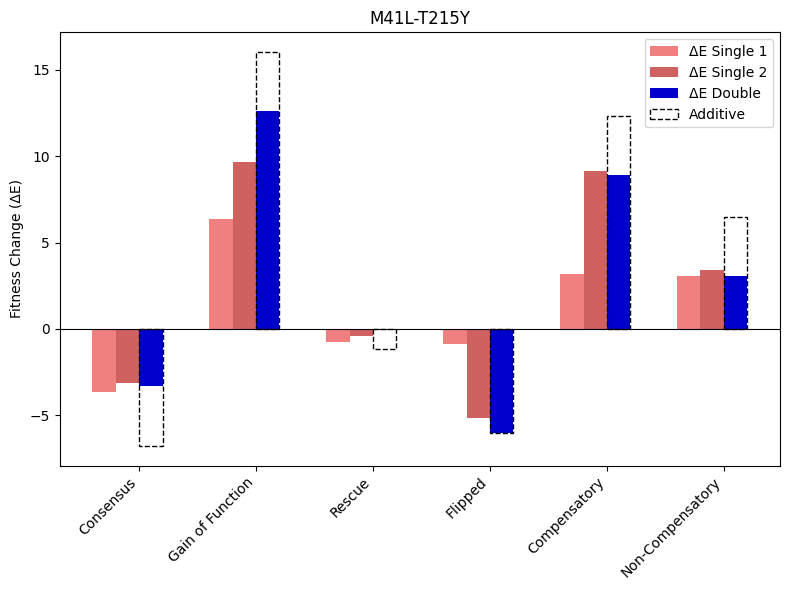

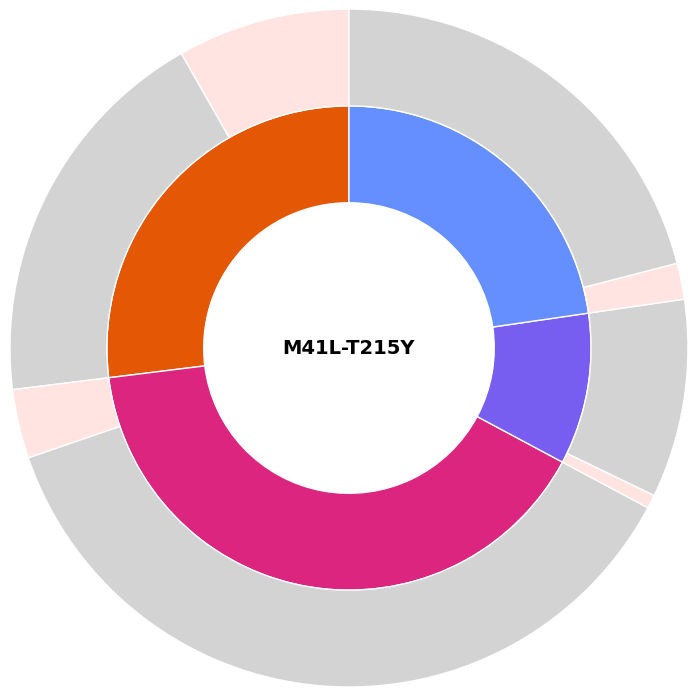

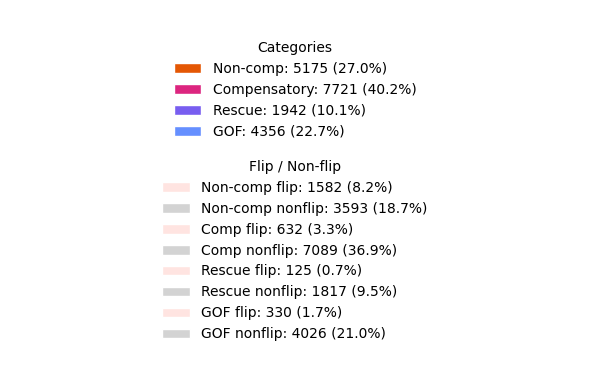

In [9]:
# RT_pair = 'F116Y-Q151M'
RT_pair = 'M41L-T215Y'

pair1, pair2 = functions.split_pairs(RT_pair)
p1_reduced = functions.unreduced_to_reduced(RT_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(RT_redux, pair2)

RT_bars = []
RT_gof_bars = []
RT_rescue_bars = []
RT_flipped_bars = []
RT_compensatory_bars = []
RT_other_bars = []

gof_counts = 0
gof_flip = 0
gof_nonflip = 0

rescue_count = 0
rescue_flip = 0
rescue_nonflip = 0

compensatory_counts = 0
compensatory_flip = 0
compensatory_nonflip = 0

noncompensatory_counts = 0
noncompensatory_flip = 0
noncompensatory_nonflip = 0

consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, RT_consensus_seq, RT_J, 39, 226)
consensus_flip_relation = consensus_result[0] - consensus_result[1]

for RT_seq in RT_all_seq:
    result_wom = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, RT_seq, RT_J, 39, 226)
    result_wm = functions.calculate_with_double_mutation_dde(p1_reduced, p2_reduced, RT_seq, RT_J, 39, 226)

    if result_wom is None:
        continue
    pair1_de, pair2_de, pair12_de, pair12_dde = result_wom

    # if result_wm is None:
    #     continue
    # pair1_de, pair2_de, pair12_de, pair12_dde = result_wm

    if pair1_de < pair12_de and pair2_de < pair12_de and pair12_de > 0:
        RT_gof_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
        gof_counts += 1

        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            RT_flipped_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
            gof_flip += 1
        else:
            gof_nonflip += 1

    elif pair1_de < pair12_de and pair2_de < pair12_de:
        RT_rescue_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
        rescue_count += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            RT_flipped_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
            rescue_flip += 1
        else:
            rescue_nonflip += 1

    elif pair1_de < pair12_de or pair2_de < pair12_de:
        RT_compensatory_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
        compensatory_counts += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            RT_flipped_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
            compensatory_flip += 1
        else:
            compensatory_nonflip += 1
    else:
        RT_other_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
        noncompensatory_counts += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            RT_flipped_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
            noncompensatory_flip += 1
        else:
            noncompensatory_nonflip += 1

RT_rescue_bars.sort(key=lambda x: x[3], reverse=True)
RT_flipped_bars.sort(key=lambda x: abs(x[1] - x[2]), reverse=True)
RT_compensatory_bars.sort(key=lambda x: x[3], reverse=True)
RT_other_bars.sort(key=lambda x: x[3], reverse=True)

RT_bars.insert(0, ('Consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
if RT_gof_bars:
    RT_bars.insert(1, ('Gain of Function', RT_gof_bars[0][1], RT_gof_bars[0][2], RT_gof_bars[0][3]))
if RT_rescue_bars:
    RT_bars.insert(2, ('Rescue', RT_rescue_bars[0][1], RT_rescue_bars[0][2], RT_rescue_bars[0][3]))
if RT_flipped_bars:
    RT_bars.insert(3, ('Flipped', RT_flipped_bars[0][1], RT_flipped_bars[0][2], RT_flipped_bars[0][3]))
if RT_compensatory_bars:
    RT_bars.insert(4, ('Compensatory', RT_compensatory_bars[0][1], RT_compensatory_bars[0][2], RT_compensatory_bars[0][3]))
if RT_other_bars:
    RT_bars.insert(5, ('Non-Compensatory', RT_other_bars[0][1], RT_other_bars[0][2], RT_other_bars[0][3]))

plot.plot_epistatic_bar(RT_pair, RT_bars[:6])
plot.epistatic_pie2(RT_pair, compensatory_flip, compensatory_nonflip, noncompensatory_flip, noncompensatory_nonflip, rescue_flip, rescue_nonflip, gof_flip, gof_nonflip)

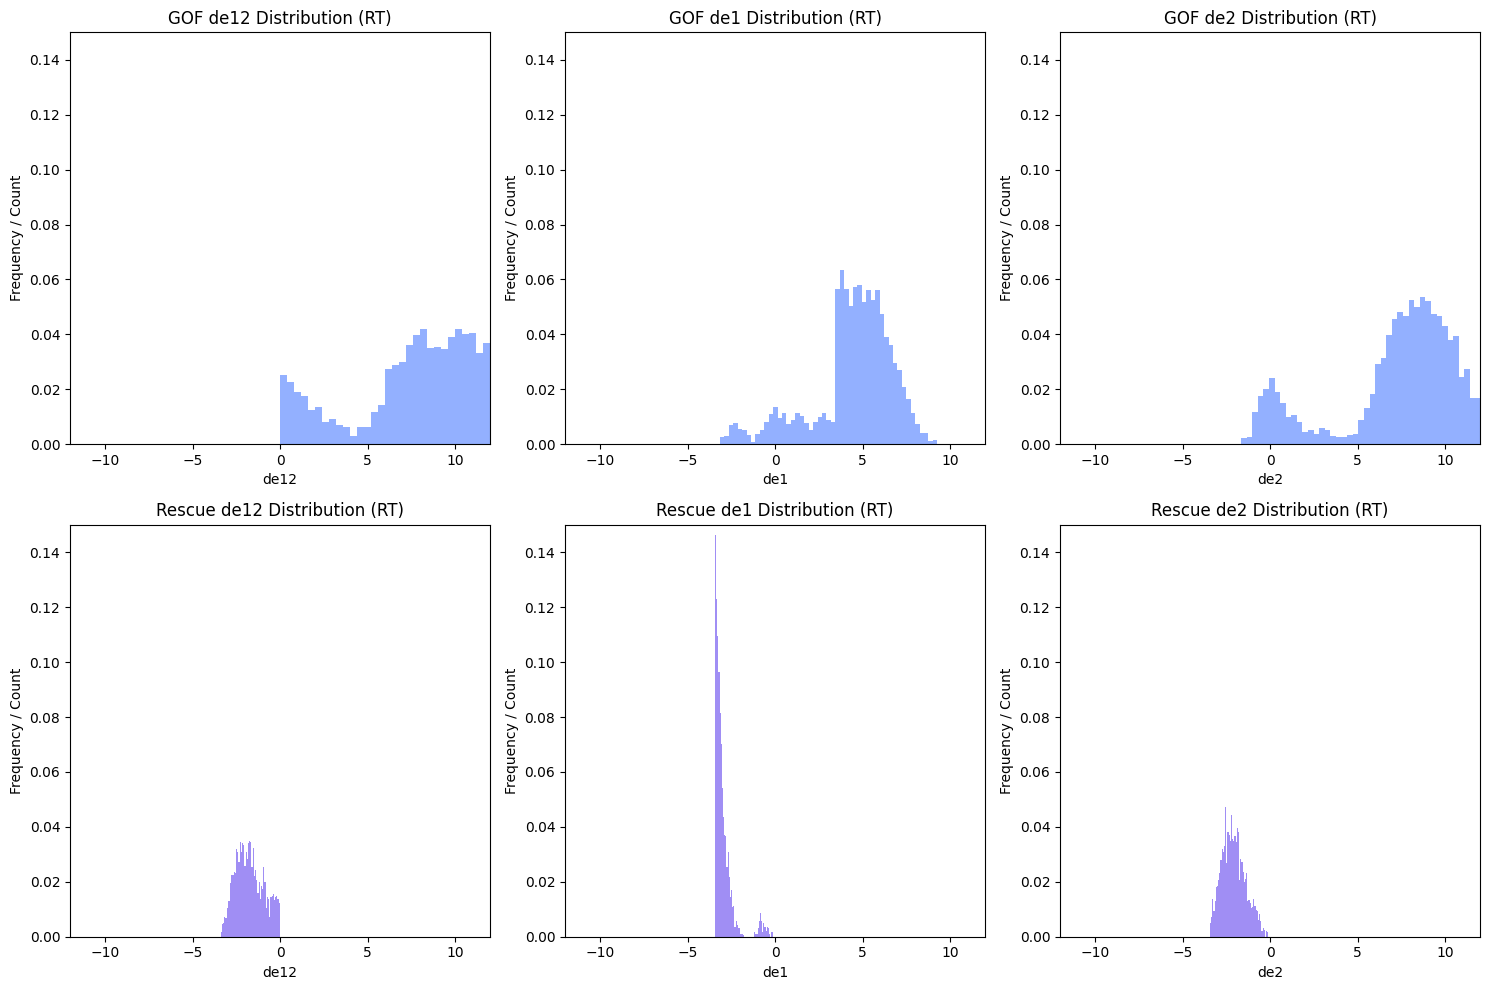

In [10]:
# Extract values for gof and rescue for RT
gof_de12 = [x[3] for x in RT_gof_bars]
gof_de1 = [x[1] for x in RT_gof_bars]
gof_de2 = [x[2] for x in RT_gof_bars]

rescue_de12 = [x[3] for x in RT_rescue_bars]
rescue_de1 = [x[1] for x in RT_rescue_bars]
rescue_de2 = [x[2] for x in RT_rescue_bars]

# Create subplots for histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot histograms for gof
axes[0, 0].hist(gof_de12, bins=bin_num, color='blue', alpha=0.7, weights=[1/gof_counts]*len(gof_de12))
axes[0, 0].set_title('GOF de12 Distribution (RT)')
axes[0, 0].set_xlabel('de12')
axes[0, 0].set_ylabel('Frequency / Count')

axes[0, 1].hist(gof_de1, bins=bin_num, color='green', alpha=0.7, weights=[1/gof_counts]*len(gof_de1))
axes[0, 1].set_title('GOF de1 Distribution (RT)')
axes[0, 1].set_xlabel('de1')
axes[0, 1].set_ylabel('Frequency / Count')

axes[0, 2].hist(gof_de2, bins=bin_num, color='red', alpha=0.7, weights=[1/gof_counts]*len(gof_de2))
axes[0, 2].set_title('GOF de2 Distribution (RT)')
axes[0, 2].set_xlabel('de2')
axes[0, 2].set_ylabel('Frequency / Count')

# Plot histograms for rescue
axes[1, 0].hist(rescue_de12, bins=bin_num, color='blue', alpha=0.7, weights=[1/rescue_count]*len(rescue_de12))
axes[1, 0].set_title('Rescue de12 Distribution (RT)')
axes[1, 0].set_xlabel('de12')
axes[1, 0].set_ylabel('Frequency / Count')

axes[1, 1].hist(rescue_de1, bins=bin_num, color='green', alpha=0.7, weights=[1/rescue_count]*len(rescue_de1))
axes[1, 1].set_title('Rescue de1 Distribution (RT)')
axes[1, 1].set_xlabel('de1')
axes[1, 1].set_ylabel('Frequency / Count')

axes[1, 2].hist(rescue_de2, bins=bin_num, color='red', alpha=0.7, weights=[1/rescue_count]*len(rescue_de2))
axes[1, 2].set_title('Rescue de2 Distribution (RT)')
axes[1, 2].set_xlabel('de2')
axes[1, 2].set_ylabel('Frequency / Count')

# Adjust layout and show the plot
colors = ['#658fff', '#785ef0']  # Blue for GOF, Purple for Rescue histograms

# Set colors for each histogram
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        for patch in ax.patches:
            patch.set_facecolor(colors[i])

for ax in axes.flatten():
    ax.set_ylim(0, 0.15)  # Adjusted for frequency
    ax.set_xlim(-12, 12)

plt.tight_layout()
plt.show()